<a href="https://colab.research.google.com/github/nguyenhoangan7941/Homework/blob/main/Homework2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install scikit-fuzzy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 920.8/920.8 kB 10.8 MB/s eta 0:00:00


179.99999999999955
50.00000000000001


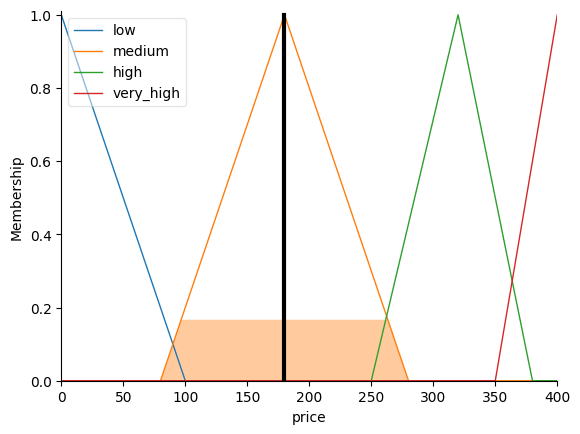

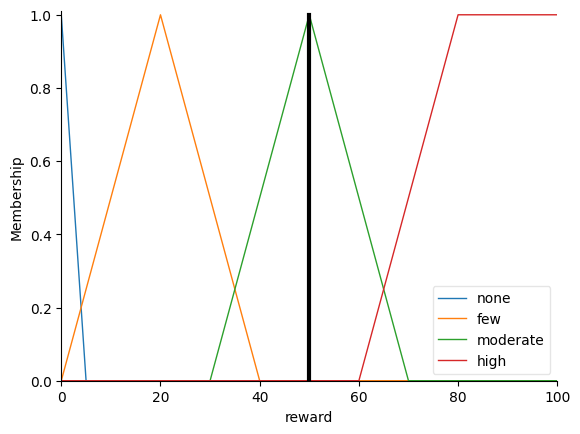

In [2]:
#Cau1
import numpy as np
import skfuzzy as fuzz
from skfuzzy import control as ctrl
ride_distance=ctrl.Antecedent(np.arange(0,50.5,0.5),'ride_distance')
traffic_condition=ctrl.Antecedent(np.arange(0,101,1),'traffic_condition')
demand_level=ctrl.Antecedent(np.arange(0,101,1),'demand_level')
weather_condition=ctrl.Antecedent(np.arange(0,10,1),'weather_condition')
customer_rating=ctrl.Antecedent(np.arange(1,5.1,0.1),'customer_rating')
ride_punctuality=ctrl.Antecedent(np.arange(0,101,1),'ride_punctuality')
price=ctrl.Consequent(np.arange(0,401,1),'price')
reward=ctrl.Consequent(np.arange(0,101,1),'reward')
ride_distance['short']=fuzz.trimf(ride_distance.universe,[0,0,3])
ride_distance['medium']=fuzz.trimf(ride_distance.universe,[2,5,8])
ride_distance['long']=fuzz.trimf(ride_distance.universe,[6,13,20])
ride_distance['very_long']=fuzz.trimf(ride_distance.universe,[15,30,50])
traffic_condition['low']=fuzz.trimf(traffic_condition.universe,[0,0,30])
traffic_condition['medium']=fuzz.trimf(traffic_condition.universe,[20,50,70])
traffic_condition['high']=fuzz.trimf(traffic_condition.universe,[60,100,100])
demand_level['low']=fuzz.trimf(demand_level.universe,[0,0,30])
demand_level['medium']=fuzz.trimf(demand_level.universe,[20,50,70])
demand_level['high']=fuzz.trimf(demand_level.universe,[60,100,100])
weather_condition['good']=fuzz.trimf(weather_condition.universe,[0,0,5])
weather_condition['moderate']=fuzz.trimf(weather_condition.universe,[3,5,8])
weather_condition['bad']=fuzz.trimf(weather_condition.universe,[6,10,10])
customer_rating['poor']=fuzz.trimf(customer_rating.universe,[1,1,2.5])
customer_rating['average']=fuzz.trimf(customer_rating.universe,[2,3,4])
customer_rating['good']=fuzz.trimf(customer_rating.universe,[3.5,5,5])
ride_punctuality['late']=fuzz.trimf(ride_punctuality.universe,[0,0,50])
ride_punctuality['on_time']=fuzz.trimf(ride_punctuality.universe,[40,60,80])
ride_punctuality['early']=fuzz.trimf(ride_punctuality.universe,[70,100,100])
price['low']=fuzz.trimf(price.universe,[0,0,100])
price['medium']=fuzz.trimf(price.universe,[80,180,280])
price['high']=fuzz.trimf(price.universe,[250,320,380])
price['very_high']=fuzz.trimf(price.universe,[350,400,400])
reward['none']=fuzz.trimf(reward.universe,[0,0,5])
reward['few']=fuzz.trimf(reward.universe,[0,20,40])
reward['moderate']=fuzz.trimf(reward.universe,[30,50,70])
reward['high']=fuzz.trapmf(reward.universe,[60,80,100,100])

rule1=ctrl.Rule(ride_distance['short']&traffic_condition['low']&demand_level['low'],price['low'])
rule2=ctrl.Rule(ride_distance['short']&traffic_condition['medium']&demand_level['high'],price['medium'])
rule3=ctrl.Rule(ride_distance['medium']&traffic_condition['high']&demand_level['high'],price['high'])
rule4=ctrl.Rule(ride_distance['long']&traffic_condition['medium']&weather_condition['good'],price['medium'])
rule5=ctrl.Rule(ride_distance['long']&traffic_condition['high']&weather_condition['bad'],price['very_high'])
rule6=ctrl.Rule(ride_distance['very_long']&traffic_condition['high']&demand_level['high'],price['very_high'])
rule7=ctrl.Rule(ride_distance['medium']&traffic_condition['low']&demand_level['low'],price['medium'])
rule8=ctrl.Rule(ride_distance['short']&traffic_condition['high']&weather_condition['bad'],price['high'])
rule9=ctrl.Rule(ride_distance['very_long']&weather_condition['bad'],price['very_high'])
rule10=ctrl.Rule(ride_distance['medium']&traffic_condition['medium']&weather_condition['moderate'],price['medium'])
rule11=ctrl.Rule(customer_rating['good']&ride_punctuality['early'],reward['high'])
rule12=ctrl.Rule(customer_rating['average']&ride_punctuality['on_time'],reward['moderate'])
rule13=ctrl.Rule(customer_rating['poor']&ride_punctuality['late'],reward['none'])
rule14=ctrl.Rule(ride_distance['long']&traffic_condition['high']&ride_punctuality['on_time'],reward['high'])
rule15=ctrl.Rule(ride_distance['medium']&traffic_condition['medium']&customer_rating['good'],reward['moderate'])
rule16=ctrl.Rule(customer_rating['poor']&ride_punctuality['late'],reward['none'])
rule17=ctrl.Rule(ride_distance['very_long']&weather_condition['bad']&customer_rating['good'],reward['high'])
rule18=ctrl.Rule(ride_distance['short']&customer_rating['average']&ride_punctuality['on_time'],reward['few'])
rule19=ctrl.Rule(ride_distance['long']&traffic_condition['high']&ride_punctuality['late'],reward['few'])
rule20=ctrl.Rule(ride_distance['medium']&customer_rating['good']&weather_condition['moderate'],reward['moderate'])

pricing_ctrl = ctrl.ControlSystem([rule1, rule2, rule3, rule4, rule5,
                                   rule6, rule7, rule8, rule9, rule10])
pricing = ctrl.ControlSystemSimulation(pricing_ctrl)

rewarding_ctrl = ctrl.ControlSystem([rule11, rule12, rule13, rule14, rule15,
                                    rule16, rule17, rule18, rule19, rule20])
rewarding = ctrl.ControlSystemSimulation(rewarding_ctrl)

pricing.input['ride_distance'] = 15
pricing.input['traffic_condition'] = 25
pricing.input['demand_level'] = 50
pricing.input['weather_condition'] = 2

rewarding.input['ride_distance'] = 15
rewarding.input['traffic_condition'] = 25
rewarding.input['weather_condition'] = 2
rewarding.input['customer_rating'] = 4
rewarding.input['ride_punctuality'] = 60

pricing.compute()
rewarding.compute()

print(pricing.output['price'])
print(rewarding.output['reward'])
price.view(sim=pricing)
reward.view(sim=rewarding)

30.000000000000007


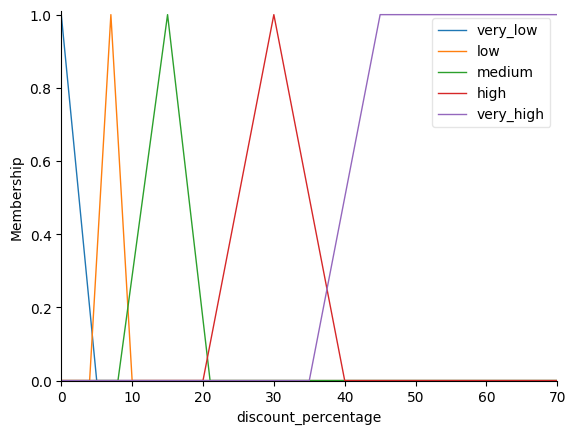

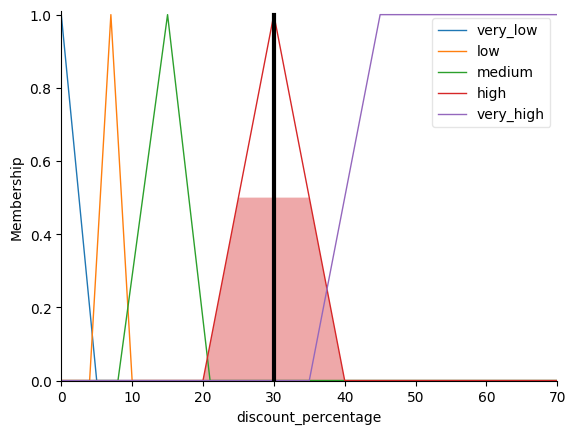

In [3]:
#Cau2
import numpy as np
import skfuzzy as fuzz
from skfuzzy import control as ctrl
rating=ctrl.Antecedent(np.arange(0,5.1,0.1),'rating')
volume=ctrl.Antecedent(np.arange(0,1001,1),'volume')
margin=ctrl.Antecedent(np.arange(0,51,1),'margin')
event=ctrl.Antecedent(np.arange(0,11,1),'event')
cdiscount=ctrl.Antecedent(np.arange(0,101,1),'cdiscount')
discount_percentage=ctrl.Consequent(np.arange(0,71,1),'discount_percentage')
rating['low']=fuzz.trimf(rating.universe,[0,0,4.1])
rating['medium']=fuzz.trimf(rating.universe,[4,4.25,4.5])
rating['high']=fuzz.trimf(rating.universe,[4.4,5,5])
volume['low']=fuzz.trimf(volume.universe,[0,0,400])
volume['medium']=fuzz.trimf(volume.universe,[350,500,700])
volume['high']=fuzz.trimf(volume.universe,[650,1000,1000])
margin['low']=fuzz.trimf(margin.universe,[0,0,15])
margin['medium']=fuzz.trimf(margin.universe,[10,20,30])
margin['high']=fuzz.trimf(margin.universe,[25,50,50])
event['none']=fuzz.trimf(event.universe,[0,0,3])
event['moderate']=fuzz.trimf(event.universe,[2,4,7])
event['high']=fuzz.trimf(event.universe,[6,10,10])
cdiscount['low']=fuzz.trimf(cdiscount.universe,[0,0,40])
cdiscount['medium']=fuzz.trimf(cdiscount.universe,[30,50,70])
cdiscount['high']=fuzz.trimf(cdiscount.universe,[40,70,100])
discount_percentage['very_low']=fuzz.trimf(discount_percentage.universe,[0,0,5])
discount_percentage['low']=fuzz.trimf(discount_percentage.universe,[4,7,10])
discount_percentage['medium']=fuzz.trimf(discount_percentage.universe,[8,15,21])
discount_percentage['high']=fuzz.trimf(discount_percentage.universe,[20,30,40])
discount_percentage['very_high']=fuzz.trapmf(discount_percentage.universe,[35,45,70,70])
discount_percentage.view()

rule1=ctrl.Rule(rating['high']&volume['high']&margin['high'],discount_percentage['very_low'])
rule2=ctrl.Rule(rating['low']&volume['low']&margin['high'],discount_percentage['high'])
rule3=ctrl.Rule(event['high']&cdiscount['high'],discount_percentage['high'])
rule4=ctrl.Rule(rating['medium']&volume['medium']&margin['medium'],discount_percentage['medium'])
rule5=ctrl.Rule(cdiscount['low']&margin['low']&volume['high'],discount_percentage['very_low'])
rule6=ctrl.Rule(rating['low']&event['none'],discount_percentage['medium'])
rule7=ctrl.Rule(volume['low']&margin['low'],discount_percentage['very_high'])

discount_ctrl = ctrl.ControlSystem([rule1, rule2, rule3, rule4, rule5,
                                   rule6, rule7])
discounting = ctrl.ControlSystemSimulation(discount_ctrl)
discounting.input['rating']=4.3
discounting.input['volume']=550
discounting.input['margin']=3
discounting.input['event']=8
discounting.input['cdiscount']=70
discounting.compute()
print(discounting.output['discount_percentage'])
discount_percentage.view(sim=discounting)


16.266666666666662


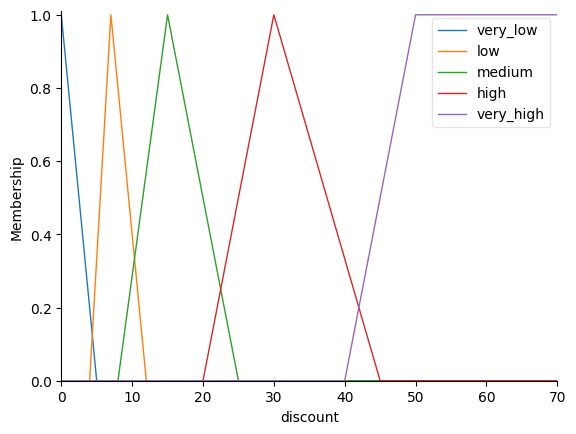

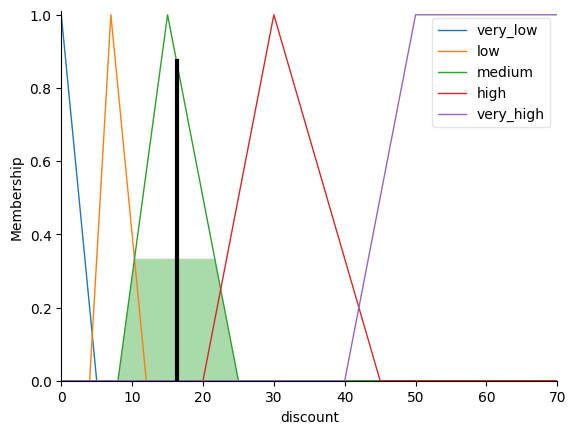

In [4]:
#Cau3
import numpy as np
import skfuzzy as fuzz
from skfuzzy import control as ctrl
demand=ctrl.Antecedent(np.arange(0,11,1),'demand')
pressure=ctrl.Antecedent(np.arange(0,11,1),'pressure')
reputation=ctrl.Antecedent(np.arange(0,5.1,0.1),'reputation')
margin=ctrl.Antecedent(np.arange(0,51,1),'margin')
seasonal=ctrl.Antecedent(np.arange(0,11,1),'seasonal')
discount=ctrl.Consequent(np.arange(0,71,1),'discount')
demand['low']=fuzz.trimf(demand.universe,[0,0,5])
demand['medium']=fuzz.trimf(demand.universe,[2,5,8])
demand['high']=fuzz.trimf(demand.universe,[5,10,10])
pressure['low']=fuzz.trimf(pressure.universe,[0,0,5])
pressure['medium']=fuzz.trimf(pressure.universe,[2,5,8])
pressure['high']=fuzz.trimf(pressure.universe,[5,10,10])
reputation['low']=fuzz.trimf(reputation.universe,[0,0,4])
reputation['medium']=fuzz.trimf(reputation.universe,[3.8,4.2,4.6])
reputation['high']=fuzz.trimf(reputation.universe,[4.3,5,5])
margin['low']=fuzz.trimf(margin.universe,[0,0,20])
margin['medium']=fuzz.trimf(margin.universe,[10,25,40])
margin['high']=fuzz.trimf(margin.universe,[30,50,50])
seasonal['none']=fuzz.trimf(seasonal.universe,[0,0,5])
seasonal['medium']=fuzz.trimf(seasonal.universe,[2,6,9])
seasonal['high']=fuzz.trimf(seasonal.universe,[5,10,10])
discount['very_low']=fuzz.trimf(discount.universe,[0,0,5])
discount['low']=fuzz.trimf(discount.universe,[4,7,12])
discount['medium']=fuzz.trimf(discount.universe,[8,15,25])
discount['high']=fuzz.trimf(discount.universe,[20,30,45])
discount['very_high']=fuzz.trapmf(discount.universe,[40,50,70,70])
discount.view()

rule1=ctrl.Rule(demand['high']&pressure['low']&margin['low'],discount['very_low'])
rule2=ctrl.Rule(demand['low']&pressure['high']&margin['high'],discount['high'])
rule3=ctrl.Rule(reputation['high']&seasonal['high']&margin['medium'],discount['medium'])
rule4=ctrl.Rule(seasonal['high']&pressure['high']&margin['high'],discount['very_high'])
rule5=ctrl.Rule(reputation['low']&margin['low']&demand['medium'],discount['medium'])
rule6=ctrl.Rule(demand['high']&seasonal['none']&pressure['low'],discount['very_low'])
rule7=ctrl.Rule(margin['high']&pressure['medium']&seasonal['medium'],discount['medium'])

discount_ctrl = ctrl.ControlSystem([rule1, rule2, rule3, rule4, rule5,
                                   rule6, rule7])
discounting = ctrl.ControlSystemSimulation(discount_ctrl)
discounting.input['demand']=9
discounting.input['pressure']=4
discounting.input['reputation']=4.2
discounting.input['margin']=40
discounting.input['seasonal']=8
discounting.compute()
print(discounting.output['discount'])
discount.view(sim=discounting)

5.0
5.000000000000001


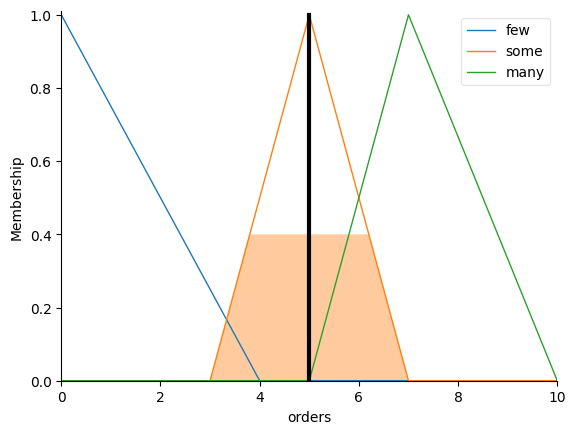

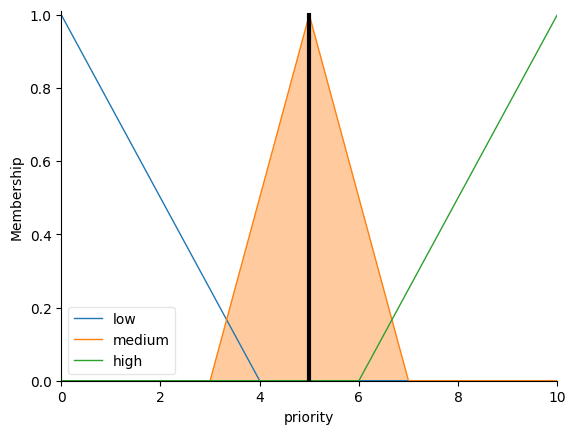

In [5]:
#Cau4
import numpy as np
import skfuzzy as fuzz
from skfuzzy import control as ctrl
density=ctrl.Antecedent(np.arange(0,11,1),'density')
urgency=ctrl.Antecedent(np.arange(0,11,1),'urgency')
load=ctrl.Antecedent(np.arange(0,11,1),'load')
traffic=ctrl.Antecedent(np.arange(0,11,1),'traffic')
profit=ctrl.Antecedent(np.arange(0,11,1),'profit')
orders=ctrl.Consequent(np.arange(0,11,1),'orders')
priority=ctrl.Consequent(np.arange(0,11,1),'priority')
for var in [density,urgency,load,traffic,profit]:
    var['low']=fuzz.trimf(var.universe,[0,0,5])
    var['medium']=fuzz.trimf(var.universe,[2,5,8])
    var['high']=fuzz.trimf(var.universe,[5,10,10])
orders['few']=fuzz.trimf(orders.universe,[0,0,4])
orders['some']=fuzz.trimf(orders.universe,[3,5,7])
orders['many']=fuzz.trimf(orders.universe,[5,7,10])
priority['low']=fuzz.trimf(priority.universe,[0,0,4])
priority['medium']=fuzz.trimf(priority.universe,[3,5,7])
priority['high']=fuzz.trimf(priority.universe,[6,10,10])

rule1=ctrl.Rule(density['high']&traffic['low']&load['low'],orders['many'])
rule2=ctrl.Rule(density['medium']&traffic['high']&urgency['medium'],orders['some'])
rule3=ctrl.Rule(load['high']&density['high']&profit['medium'],orders['some'])
rule4=ctrl.Rule(density['low']&urgency['high']&traffic['medium'],orders['some'])
rule5=ctrl.Rule(profit['high']&urgency['high']&traffic['high'],orders['some'])
rule6=ctrl.Rule(density['high']&load['low']&traffic['medium'],orders['some'])

rule7=ctrl.Rule(urgency['high']&profit['high'],priority['high'])
rule8=ctrl.Rule(urgency['medium']&traffic['medium'],priority['medium'])
rule9=ctrl.Rule(urgency['low']&profit['low']&density['high'],priority['low'])

ordering_ctrl = ctrl.ControlSystem([rule1, rule2, rule3, rule4, rule5,rule6])
prior_ity_ctrl = ctrl.ControlSystem([rule9, rule7, rule8])
ordering = ctrl.ControlSystemSimulation(ordering_ctrl)
prior=ctrl.ControlSystemSimulation(prior_ity_ctrl)
ordering.input['density']=9
ordering.input['urgency']=5
ordering.input['load']=3
ordering.input['traffic']=5
ordering.input['profit']=5
ordering.compute()
prior.input['urgency']=5
prior.input['profit']=5
prior.input['density']=9
prior.input['traffic']=5
prior.compute()
print(ordering.output['orders'])
print(prior.output['priority'])
orders.view(sim=ordering)
priority.view(sim=prior)



